# Post-Quantum Key Establishment with ML-KEM

## Goal

This notebook demonstrates **ML-KEM**, a post-quantum key encapsulation mechanism.

This is the final notebook in the project sequence:

```text
RSA → Classical Factoring → Shor's Algorithm → Grover's Algorithm → ML-KEM
```

The earlier notebooks showed that RSA depends on the difficulty of factoring. Shor's algorithm demonstrates why integer factorization is a quantum threat to RSA. This notebook shows a post-quantum alternative for **key establishment**.

## Main result

Alice and Bob use ML-KEM to establish the same shared secret without sending the secret directly.

## Important note

ML-KEM is **not direct message encryption** like the toy RSA example. ML-KEM is a **key encapsulation mechanism**. The shared secret produced by ML-KEM can later be used with a symmetric encryption algorithm, such as AES.

## How to use this notebook

This version is designed to be run in **Google Colab first**. After all cells run successfully in Colab, download the completed notebook to your Mac and upload it to GitHub.


## 1. Google Colab Setup

Run this cell in **Google Colab** before running the rest of the notebook.

Why this is needed:

- `liboqs-python` depends on the underlying Open Quantum Safe `liboqs` C library.
- Running locally on macOS may require extra build tools such as CMake.
- Google Colab provides a cleaner Linux environment for this project, so it is easier to run first in Colab and then download the completed notebook.


In [1]:
# ======================================================
# Google Colab install cell for Post-Quantum ML-KEM
# Run this cell FIRST in Google Colab.
# ======================================================

import os
import sys
import subprocess
import shutil
from pathlib import Path

IN_COLAB = Path("/content").exists()

if not IN_COLAB:
    raise RuntimeError(
        "This notebook is meant to be run in Google Colab first. "
        "Open it in Colab, run all cells, then download the completed notebook to your Mac. "
        "Local macOS runs may require CMake and other build tools."
    )

os.chdir("/content")

print("Running in Google Colab.")
print("Installing system build tools...")

# Colab usually already has many of these tools, but this makes the setup safer.
subprocess.run(["apt-get", "update", "-qq"], check=True)
subprocess.run(
    ["apt-get", "install", "-y", "-qq", "cmake", "ninja-build", "libssl-dev", "git"],
    check=True
)

print("Installing Python libraries...")
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "numpy", "pandas", "matplotlib"],
    check=True
)

repo_path = Path("/content/liboqs-python")

if repo_path.exists():
    print("liboqs-python repository already exists. Reusing it.")
else:
    print("Cloning liboqs-python...")
    subprocess.run(
        ["git", "clone", "--depth=1", "https://github.com/open-quantum-safe/liboqs-python", str(repo_path)],
        check=True
    )

print("Installing liboqs-python...")
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", str(repo_path)],
    check=True
)

print("Installation cell finished.")

Running in Google Colab.
Installing system build tools...
Installing Python libraries...
Cloning liboqs-python...
Installing liboqs-python...
Installation cell finished.


In [2]:
# ======================================================
# Verify ML-KEM installation and set up figure folder
# ======================================================

import os
import time
import statistics
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import oqs

# In Colab, save figures to /content/figures.
# In GitHub repo structure, you can later move these into the repo's figures/ folder.
FIGURE_DIR = Path("/content/figures") if Path("/content").exists() else Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Figures will be saved to:", FIGURE_DIR.resolve())
print("liboqs version:", oqs.oqs_version())
print("liboqs-python version:", oqs.oqs_python_version())

enabled_kems = oqs.get_enabled_kem_mechanisms()
ml_kem_algorithms = [alg for alg in enabled_kems if alg.startswith("ML-KEM")]

print("Available ML-KEM algorithms:")
print(ml_kem_algorithms)

required_algorithms = ["ML-KEM-512", "ML-KEM-768", "ML-KEM-1024"]
missing = [alg for alg in required_algorithms if alg not in ml_kem_algorithms]

if missing:
    print("Warning: These expected ML-KEM algorithms are not enabled in this build:", missing)
else:
    print("All expected ML-KEM parameter sets are available.")

liboqs-python faulthandler is disabled


INFO:oqs.oqs:liboqs-python faulthandler is disabled


liboqs not found, installing it in /root/_oqs


INFO:oqs.oqs:liboqs not found, installing it in /root/_oqs


Installing in 5 seconds...


...

INFO:oqs.oqs:Installing in 1 seconds...


Done installing liboqs


INFO:oqs.oqs:Done installing liboqs


Figures will be saved to: /content/figures
liboqs version: 0.15.0
liboqs-python version: 0.16.0.dev0
Available ML-KEM algorithms:
['ML-KEM-512', 'ML-KEM-768', 'ML-KEM-1024']
All expected ML-KEM parameter sets are available.


/usr/local/lib/python3.12/dist-packages/oqs/__init__.py:1: UserWarning: liboqs version (major, minor) 0.15.0 differs from liboqs-python version 0.16.0.dev0
  from oqs.oqs import (


## 2. ML-KEM Workflow

The workflow is:

1. Alice generates an ML-KEM public/private key pair.
2. Alice shares her public key.
3. Bob uses Alice's public key to encapsulate a shared secret.
4. Bob sends the ciphertext to Alice.
5. Alice decapsulates the ciphertext using her private key.
6. Alice and Bob now have the same shared secret.

The shared secret itself is **not sent** over the network.


## 3. Single ML-KEM Demonstration

This first experiment uses `ML-KEM-512`.

The purpose is to show the basic key-establishment flow:

```text
Alice public key → Bob encapsulates → Bob sends ciphertext → Alice decapsulates
```

At the end, Alice and Bob should have the same shared secret.


In [3]:
# ======================================================
# Experiment 1: ML-KEM key establishment demo
# ======================================================

kemalg = "ML-KEM-512"

with oqs.KeyEncapsulation(kemalg) as alice:
    with oqs.KeyEncapsulation(kemalg) as bob:

        # Alice generates public/private key pair.
        public_key_alice = alice.generate_keypair()

        # Bob encapsulates a shared secret using Alice's public key.
        ciphertext, shared_secret_bob = bob.encap_secret(public_key_alice)

        # Alice decapsulates Bob's ciphertext to recover the same shared secret.
        shared_secret_alice = alice.decap_secret(ciphertext)

        print("===== ML-KEM Single Demo =====")
        print(f"Algorithm: {kemalg}")
        print(f"Public key length: {len(public_key_alice)} bytes")
        print(f"Ciphertext length: {len(ciphertext)} bytes")
        print(f"Shared secret length: {len(shared_secret_alice)} bytes")
        print(f"Shared secrets match: {shared_secret_alice == shared_secret_bob}")

        assert shared_secret_alice == shared_secret_bob


===== ML-KEM Single Demo =====
Algorithm: ML-KEM-512
Public key length: 800 bytes
Ciphertext length: 768 bytes
Shared secret length: 32 bytes
Shared secrets match: True


## 4. Compare ML-KEM Parameter Sets

ML-KEM has multiple parameter sets. In this notebook, I compare:

| Parameter Set | General Meaning |
|---|---|
| ML-KEM-512 | Smaller public key and ciphertext size |
| ML-KEM-768 | Middle option with larger parameters |
| ML-KEM-1024 | Largest option among these three |

In general, larger parameter sets increase communication cost because the public key and ciphertext become larger.


In [4]:
# ======================================================
# Experiment 2: Compare ML-KEM parameter sets
# ======================================================

algorithms = ["ML-KEM-512", "ML-KEM-768", "ML-KEM-1024"]

results = []

for alg in algorithms:
    if alg not in oqs.get_enabled_kem_mechanisms():
        print(f"{alg} is not enabled in this liboqs build. Skipping.")
        continue

    with oqs.KeyEncapsulation(alg) as alice:
        with oqs.KeyEncapsulation(alg) as bob:

            start = time.perf_counter()
            public_key = alice.generate_keypair()
            keygen_time = time.perf_counter() - start

            start = time.perf_counter()
            ciphertext, shared_secret_bob = bob.encap_secret(public_key)
            encap_time = time.perf_counter() - start

            start = time.perf_counter()
            shared_secret_alice = alice.decap_secret(ciphertext)
            decap_time = time.perf_counter() - start

            secrets_match = shared_secret_alice == shared_secret_bob
            assert secrets_match

            results.append({
                "Algorithm": alg,
                "Public key bytes": len(public_key),
                "Ciphertext bytes": len(ciphertext),
                "Shared secret bytes": len(shared_secret_alice),
                "Keygen time": keygen_time,
                "Encapsulation time": encap_time,
                "Decapsulation time": decap_time,
                "Shared secrets match": secrets_match
            })

df_mlkem = pd.DataFrame(results)
df_mlkem


,Algorithm,Public key bytes,Ciphertext bytes,Shared secret bytes,Keygen time,Encapsulation time,Decapsulation time,Shared secrets match
0,ML-KEM-512,800,768,32,0.000277,0.000162,0.000038,True
1,ML-KEM-768,1184,1088,32,0.000181,0.000166,0.000054,True
2,ML-KEM-1024,1568,1568,32,0.000212,0.000069,0.000057,True


## 5. Public Key and Ciphertext Size Figure

This figure compares the size of the public key and ciphertext for each ML-KEM parameter set.

This is one of the most useful figures for the GitHub README because it visually shows the tradeoff between parameter set size and communication cost.


Saved figure to: /content/figures/mlkem_key_ciphertext_size_comparison.png


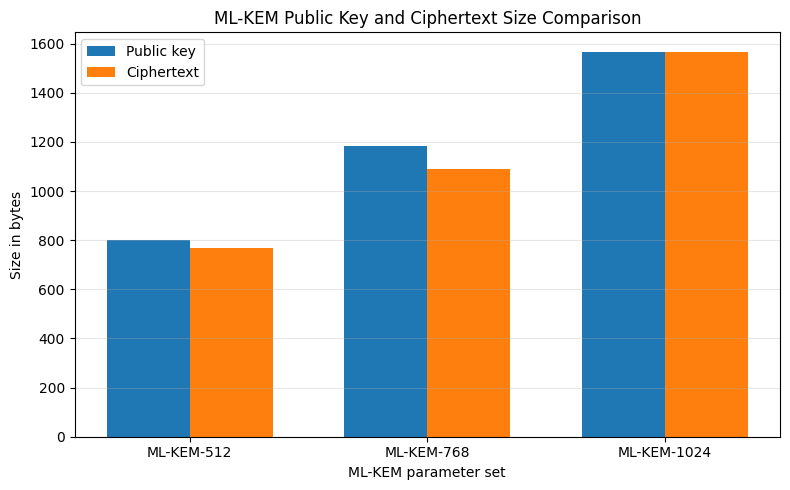

In [5]:
# ======================================================
# Figure 1: ML-KEM public key and ciphertext size comparison
# ======================================================

x = np.arange(len(df_mlkem["Algorithm"]))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    x - width / 2,
    df_mlkem["Public key bytes"],
    width,
    label="Public key"
)

ax.bar(
    x + width / 2,
    df_mlkem["Ciphertext bytes"],
    width,
    label="Ciphertext"
)

ax.set_xlabel("ML-KEM parameter set")
ax.set_ylabel("Size in bytes")
ax.set_title("ML-KEM Public Key and Ciphertext Size Comparison")
ax.set_xticks(x)
ax.set_xticklabels(df_mlkem["Algorithm"])
ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

output_path = FIGURE_DIR / "mlkem_key_ciphertext_size_comparison.png"
fig.savefig(output_path, bbox_inches="tight", dpi=200)

print("Saved figure to:", output_path)
plt.show()


## 6. Runtime Benchmark

The previous comparison only runs each algorithm once. A single run is useful for demonstration, but it is not a strong benchmark.

The next cell runs each algorithm multiple times and reports:

- Average key generation time
- Average encapsulation time
- Average decapsulation time
- Standard deviation for each operation

These results are still environment-dependent, so they should be interpreted as an educational comparison, not a formal cryptographic benchmark.


In [6]:
# ======================================================
# Experiment 3: Repeated runtime benchmark
# ======================================================

trials = 100
benchmark_results = []

for alg in algorithms:
    if alg not in oqs.get_enabled_kem_mechanisms():
        continue

    keygen_times = []
    encap_times = []
    decap_times = []

    for _ in range(trials):
        with oqs.KeyEncapsulation(alg) as alice:
            with oqs.KeyEncapsulation(alg) as bob:

                start = time.perf_counter()
                public_key = alice.generate_keypair()
                keygen_times.append(time.perf_counter() - start)

                start = time.perf_counter()
                ciphertext, shared_secret_bob = bob.encap_secret(public_key)
                encap_times.append(time.perf_counter() - start)

                start = time.perf_counter()
                shared_secret_alice = alice.decap_secret(ciphertext)
                decap_times.append(time.perf_counter() - start)

                assert shared_secret_alice == shared_secret_bob

    benchmark_results.append({
        "Algorithm": alg,
        "Trials": trials,
        "Avg keygen time": statistics.mean(keygen_times),
        "Avg encapsulation time": statistics.mean(encap_times),
        "Avg decapsulation time": statistics.mean(decap_times),
        "Std keygen time": statistics.stdev(keygen_times),
        "Std encapsulation time": statistics.stdev(encap_times),
        "Std decapsulation time": statistics.stdev(decap_times),
    })

df_benchmark = pd.DataFrame(benchmark_results)
df_benchmark


,Algorithm,Trials,Avg keygen time,Avg encapsulation time,Avg decapsulation time,Std keygen time,Std encapsulation time,Std decapsulation time
0,ML-KEM-512,100,0.000036,0.000040,0.000079,0.000019,0.000059,0.000298
1,ML-KEM-768,100,0.000052,0.000047,0.000046,0.000050,0.000010,0.000008
2,ML-KEM-1024,100,0.000064,0.000067,0.000064,0.000019,0.000023,0.000014


Saved figure to: /content/figures/mlkem_average_runtime_comparison.png


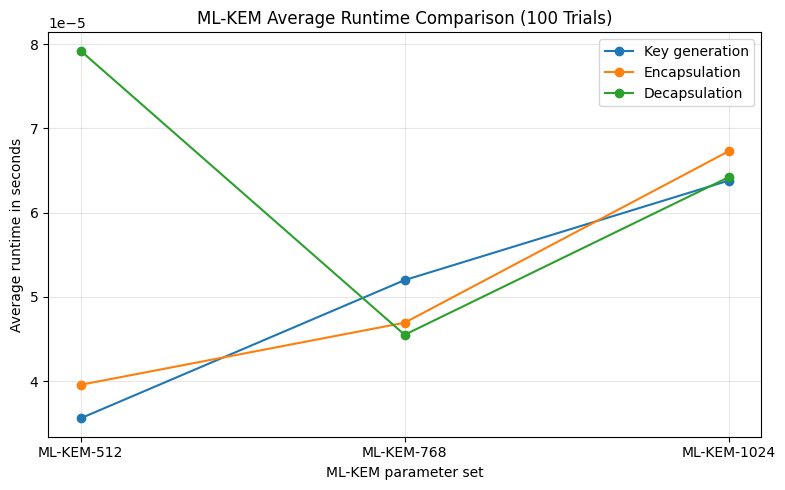

In [7]:
# ======================================================
# Figure 2: ML-KEM average runtime comparison
# ======================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    df_benchmark["Algorithm"],
    df_benchmark["Avg keygen time"],
    marker="o",
    label="Key generation"
)

ax.plot(
    df_benchmark["Algorithm"],
    df_benchmark["Avg encapsulation time"],
    marker="o",
    label="Encapsulation"
)

ax.plot(
    df_benchmark["Algorithm"],
    df_benchmark["Avg decapsulation time"],
    marker="o",
    label="Decapsulation"
)

ax.set_xlabel("ML-KEM parameter set")
ax.set_ylabel("Average runtime in seconds")
ax.set_title(f"ML-KEM Average Runtime Comparison ({trials} Trials)")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()

output_path = FIGURE_DIR / "mlkem_average_runtime_comparison.png"
fig.savefig(output_path, bbox_inches="tight", dpi=200)

print("Saved figure to:", output_path)
plt.show()


## 7. Result Interpretation

The experiment should show that all available ML-KEM parameter sets successfully establish matching shared secrets.

The size comparison usually shows that public key size and ciphertext size increase from `ML-KEM-512` to `ML-KEM-1024`.

The runtime comparison is useful for observing the workflow, but the exact timing depends on:

1. The machine running the notebook
2. Python overhead
3. The installed `liboqs` version
4. Background system load

Therefore, the timing result should not be presented as a formal benchmark.


## 8. Connection Back to RSA, Shor, and Grover

This ML-KEM notebook completes the full project story.

| Method | Role in Project | Main Idea |
|---|---|---|
| RSA | Classical baseline | Public-key encryption based on factoring difficulty |
| Classical factoring | Attack baseline | Factoring `n` allows private-key recovery |
| Shor's Algorithm | Quantum attack | Uses order-finding to factor the RSA modulus |
| Grover's Algorithm | Quantum search demonstration | Amplifies the correct state in a search space |
| ML-KEM | Post-quantum defense | Establishes a shared secret without relying on factoring |

ML-KEM responds to the RSA problem by using a different mathematical foundation instead of integer factorization.


In [8]:
project_comparison = pd.DataFrame([
    {
        "Method": "RSA",
        "Role in project": "Classical baseline",
        "Mathematical basis": "Integer factorization",
        "Quantum relevance": "Vulnerable to Shor's algorithm"
    },
    {
        "Method": "Classical factoring",
        "Role in project": "Attack baseline",
        "Mathematical basis": "Trial division for toy example",
        "Quantum relevance": "Shows why factoring breaks RSA"
    },
    {
        "Method": "Shor's Algorithm",
        "Role in project": "Quantum attack",
        "Mathematical basis": "Order finding",
        "Quantum relevance": "Can factor RSA modulus on a sufficient quantum computer"
    },
    {
        "Method": "Grover's Algorithm",
        "Role in project": "Quantum search demonstration",
        "Mathematical basis": "Amplitude amplification",
        "Quantum relevance": "Quadratic speedup for brute-force search"
    },
    {
        "Method": "ML-KEM",
        "Role in project": "Post-quantum defense",
        "Mathematical basis": "Module-LWE / lattice-based cryptography",
        "Quantum relevance": "Designed for post-quantum key establishment"
    }
])

project_comparison


,Method,Role in project,Mathematical basis,Quantum relevance
0,RSA,Classical baseline,Integer factorization,Vulnerable to Shor's algorithm
1,Classical factoring,Attack baseline,Trial division for toy example,Shows why factoring breaks RSA
2,Shor's Algorithm,Quantum attack,Order finding,Can factor RSA modulus on a sufficient quantum...
3,Grover's Algorithm,Quantum search demonstration,Amplitude amplification,Quadratic speedup for brute-force search
4,ML-KEM,Post-quantum defense,Module-LWE / lattice-based cryptography,Designed for post-quantum key establishment


## 9. Final Summary

| Question | Answer |
|---|---|
| What was tested? | ML-KEM key establishment |
| What algorithms were compared? | ML-KEM-512, ML-KEM-768, and ML-KEM-1024 |
| What was the main result? | Alice and Bob produced matching shared secrets |
| What figures were saved? | Key/ciphertext size comparison and average runtime comparison |
| Why does this matter? | ML-KEM provides a post-quantum key-establishment approach that does not rely on RSA-style factoring |
| Main limitation | This notebook uses a library implementation and educational timing measurements |

## Limitations

This notebook uses a library implementation of ML-KEM rather than implementing the full lattice arithmetic from scratch. This is appropriate because ML-KEM is a complex cryptographic scheme.

The goal of this section is to demonstrate how post-quantum key establishment works and how it responds to the RSA vulnerability shown by Shor's algorithm.

Important limitations:

1. This is not a from-scratch implementation of ML-KEM.
2. Runtime measurements depend on the execution environment.
3. The benchmark is educational, not formal.
4. The notebook demonstrates key establishment, not full message encryption.

## Suggested future work

A strong next step would be to build a hybrid workflow:

```text
ML-KEM establishes shared secret → derive AES key → AES encrypts the actual message
```

That would show how post-quantum key establishment can be connected to real encrypted communication.
